# Early Fusion
**Channels:** Original (3) + Occluded (3) + Eye-Tracking Map (1) = **7**
All inputs are concatenated at the input level before being passed through the network.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

!pip install timm mediapipe --quiet

import os, random, urllib.request
import numpy as np
import pandas as pd
import cv2
import timm
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_curve, auc)

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import face_landmarker
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model_url  = 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'
model_path = '/content/face_landmarker.task'

if not os.path.exists(model_path):
    print('Downloading face landmarker...')
    urllib.request.urlretrieve(model_url, model_path)
    print('Done!')
else:
    print('Model already downloaded.')

Model already downloaded.


## Occlusion

In [ ]:
#responsible for occluding facial regions based on detected landmarks
class FacialRegionOcclusion:

    REGION_INDICES = {
        'left_eye':  [33, 160, 158, 133, 153, 144],
        'right_eye': [362, 385, 387, 263, 373, 380],
        'nose':      [1, 2, 98, 327, 168, 195],
    }

    def __init__(self, regions=['left_eye', 'right_eye', 'nose'],occlusion_value=0, model_path='/content/face_landmarker.task'):
        self.regions         = regions
        self.region_indices  = self.REGION_INDICES
        self.occlusion_value = occlusion_value

        base_options = python.BaseOptions(model_asset_path=model_path)
        options = face_landmarker.FaceLandmarkerOptions(base_options=base_options,running_mode=VisionTaskRunningMode.IMAGE)
        self.landmarker = face_landmarker.FaceLandmarker.create_from_options(options)

    def get_landmarks(self, image_np):
        if image_np.dtype != np.uint8:
            image_np = image_np.astype(np.uint8)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_np)
        results  = self.landmarker.detect(mp_image)
        if not results.face_landmarks:
            return None
        lm = results.face_landmarks[0]
        return [(int(l.x * image_np.shape[1]), int(l.y * image_np.shape[0])) for l in lm]

    def occlude_region(self, image_np, landmarks, region_name):
        indices  = self.region_indices[region_name]
        points   = np.array([landmarks[i] for i in indices], dtype=np.int32)
        cx = int(np.mean([p[0] for p in points]))
        cy = int(np.mean([p[1] for p in points]))
        h, w = image_np.shape[:2]\
        
        box  = {'left_eye': 0.25, 'right_eye': 0.25, 'nose': 0.25}.get(region_name, 0.12)
        bh, bw = int(h * box), int(w * box)
        top,  bottom = max(0, cy - bh//2), min(h, cy + bh//2)
        left, right  = max(0, cx - bw//2), min(w, cx + bw//2)
        image_np[top:bottom, left:right] = int(self.occlusion_value * 255)
        return image_np

    def __call__(self, pil_image):
        image_np  = np.array(pil_image)
        landmarks = self.get_landmarks(image_np)
        if landmarks is None:
            return pil_image
        occluded = image_np.copy()
        for region in self.regions:
            occluded = self.occlude_region(occluded, landmarks, region)
        return Image.fromarray(occluded)

## 2. Dataset — 7 channels

In [ ]:
# Eye-tracking feature columns (20 numeric features → 1 spatial channel)
EYE_FEATURES = [
    'left_pupil_x','left_pupil_y','left_relative_pupil_x','left_relative_pupil_y',
    'left_eye_center_x','left_eye_center_y','left_eye_width','left_eye_height','left_ear',
    'right_pupil_x','right_pupil_y','right_relative_pupil_x','right_relative_pupil_y',
    'right_eye_center_x','right_eye_center_y','right_eye_width','right_eye_height','right_ear',
    'avg_ear','eye_openness_pct'
]

class SevenChannelDataset(Dataset):

    CLASS_MAP = {'anger':0, 'fear':1, 'joy':2, 'Natural':3, 'sadness':4, 'surprise':5}

    def __init__(self, root_dir, csv_path, occlusion_regions, preprocess=None, scaler=None):
        self.preprocess        = preprocess
        self.occlusion_regions = occlusion_regions
        self.samples           = []

        # ── Step 1: Load eye-tracking CSV ──────────────────────────
        df = pd.read_csv(csv_path)
        df[EYE_FEATURES] = df[EYE_FEATURES].fillna(0)

        # ── Step 2: Scale features ─────────────────────────────────

        if scaler is None:
            scaler = StandardScaler()
            df[EYE_FEATURES] = scaler.fit_transform(df[EYE_FEATURES])
        else:
            df[EYE_FEATURES] = scaler.transform(df[EYE_FEATURES])

        self.scaler = scaler  # save so you can pass it to val/test datasets

        # Index rows by image filename for fast lookup
        self.eye_df = df.set_index('image_file')

        # ── Step 3: Create one occluder per region 
        self.occluders = {
            r: FacialRegionOcclusion(regions=[r]) for r in occlusion_regions
        }

        # ── Step 4: Collect all image paths + labels ───────────────
        root_dir = Path(root_dir)
        for class_name, label in self.CLASS_MAP.items():
            class_dir = root_dir / class_name
            if not class_dir.exists():
                print(f'Warning: {class_dir} not found, skipping.')
                continue
            for img_path in class_dir.glob('*.jpg'):
                self.samples.append((img_path, label))

        print(f'Total samples: {len(self.samples)}')

    def __len__(self):
        return len(self.samples)

    def _get_eye_channel(self, filename, img_size=224):
        """
        Turns 20 scalar eye-tracking features into a (1, 224, 224) tensor.

        Each of the 20 features fills a horizontal stripe of the canvas.
        The model can then learn to respond to each feature spatially.
        """

        # Look up this image's eye features, or use zeros if not found
        if filename in self.eye_df.index:
            feats = self.eye_df.loc[filename, EYE_FEATURES].values.astype(np.float32)
        else:
            feats = np.zeros(len(EYE_FEATURES), dtype=np.float32)  # 20 zeros

        num_feats = len(feats)           # 20
        canvas    = np.zeros((img_size, img_size), dtype=np.float32)  # blank 224x224

        # Divide 224 rows evenly across 20 features
        # Using np.array_split avoids the leftover-pixel bug
        row_splits = np.array_split(range(img_size), num_feats)

        for i, row_indices in enumerate(row_splits):
            # Fill every row in this stripe with the feature's value
            canvas[row_indices, :] = feats[i].item()

        # Add a channel dimension: (224, 224) → (1, 224, 224)
        return torch.tensor(canvas).unsqueeze(0)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        pil_image       = Image.open(img_path).convert('RGB')

        # Channels 1–3: the original image
        original = self.preprocess(pil_image)

        # Channels 4–6: the image with one random facial region blacked out
        region   = random.choice(self.occlusion_regions)
        occ_pil  = self.occluders[region](pil_image)
        occluded = self.preprocess(occ_pil)

        # Channel 7: eye-tracking feature map
        eye_ch = self._get_eye_channel(img_path.name)

        # Stack all 7 channels together: (3+3+1) = (7, 224, 224)
        stacked = torch.cat([original, occluded, eye_ch], dim=0)

        return stacked, label, original, occluded

In [ ]:
# ── Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

CSV_PATH        = '/content/drive/MyDrive/Autism_Dataset/outputstry/eye_metrics.csv'
TRAIN_DIR       = '/content/drive/MyDrive/Autism_Dataset/original_train'
TEST_DIR        = '/content/drive/MyDrive/Autism_Dataset/test'
OCCLUSION_REGS  = ['left_eye', 'right_eye', 'nose']

train_data = SevenChannelDataset(TRAIN_DIR, CSV_PATH, OCCLUSION_REGS, train_transform)
test_data  = SevenChannelDataset(TEST_DIR,  CSV_PATH, OCCLUSION_REGS, val_transform)

train_size = int(0.8 * len(train_data))
val_size   = len(train_data) - train_size
train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          collate_fn=lambda b: (torch.stack([x[0] for x in b]),
                                                torch.tensor([x[1] for x in b]),
                                                [x[2] for x in b], [x[3] for x in b]))
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          collate_fn=lambda b: (torch.stack([x[0] for x in b]),
                                                torch.tensor([x[1] for x in b]),
                                                [x[2] for x in b], [x[3] for x in b]))
test_loader  = DataLoader(test_data,     batch_size=32, shuffle=False,
                          collate_fn=lambda b: (torch.stack([x[0] for x in b]),
                                                torch.tensor([x[1] for x in b]),
                                                [x[2] for x in b], [x[3] for x in b]))

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_data)}')

Total samples: 1195
Total samples: 226
Train: 956 | Val: 239 | Test: 226


## 4. Models (7-channel input)

In [ ]:

class ResNet18_7ch(nn.Module):
    """Pretrained ResNet18 with an added input adapter for 7 channels."""
    def __init__(self, num_classes=6, pretrained=True):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)

        # Extra conv to blend channels 4-7 before the pretrained stem
        self.channel_adapter = nn.Sequential(
            nn.Conv2d(7, 3, kernel_size=1, bias=False),  # project 7 → 3
            nn.BatchNorm2d(3),
            nn.ReLU()
        )
        # Keep ALL pretrained weights untouched
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # drop final FC

        # Custom head
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.channel_adapter(x)   # (B,7,H,W) → (B,3,H,W)
        x = self.backbone(x)           # (B,512,1,1)
        return self.head(x)

In [ ]:
# ── D. ViT — pretrained + channel adapter ──────────────────────
class ViT_7ch(nn.Module):
    """Pretrained ViT-Base/32 with a learned 7→3 channel adapter."""
    def __init__(self, num_classes=6, pretrained=True):
        super().__init__()
        self.channel_adapter = nn.Sequential(
            nn.Conv2d(7, 3, kernel_size=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )

        self.vit = timm.create_model(
            'vit_base_patch32_224',
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        x = self.channel_adapter(x)
        return self.vit(x)

In [ ]:
class multi_scaleVit(nn.Module):
    def __init__(self, num_classes=6, pretrained=True):
        super().__init__()
        self.channel_adapter = nn.Sequential(
            nn.Conv2d(7, 3, kernel_size=1, bias=False),
            nn.BatchNorm2d(3),
            nn.ReLU()
        )

        self.multi_vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        x = self.channel_adapter(x)
        return self.multi_vit(x)

## 5. Training & Evaluation

In [ ]:
def training(model, num_epochs, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    for epoch in range(num_epochs):
        # ── Train ──
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for images, labels, *_ in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            t_loss    += loss.item()
            t_correct += out.argmax(1).eq(labels).sum().item()
            t_total   += labels.size(0)

        # ── Validate ──
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels, *_ in val_loader:
                images, labels = images.to(device), labels.to(device)
                out  = model(images)
                v_loss    += criterion(out, labels).item()
                v_correct += out.argmax(1).eq(labels).sum().item()
                v_total   += labels.size(0)

        scheduler.step()
        print(f'Epoch [{epoch+1}/{num_epochs}]  '
              f'Train Loss: {t_loss/len(train_loader):.4f}  Acc: {100*t_correct/t_total:.2f}%  |  '
              f'Val Loss: {v_loss/len(val_loader):.4f}  Acc: {100*v_correct/v_total:.2f}%')

    return model

In [ ]:
def test_phase(model, test_loader, device, model_name='model'):
    model.eval()
    criterion   = nn.CrossEntropyLoss()
    class_names = list(SevenChannelDataset.CLASS_MAP.keys())

    test_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels, *_ in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)

            test_loss += criterion(outputs, labels).item()
            correct   += preds.eq(labels).sum().item()
            total     += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    # ── Metrics ──
    cm          = confusion_matrix(all_labels, all_preds)
    precision   = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall      = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1          = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    specificities = []
    for c in range(len(class_names)):
        tp = cm[c,c]; fp = cm[:,c].sum()-tp
        fn = cm[c,:].sum()-tp; tn = cm.sum()-tp-fp-fn
        specificities.append(tn/(tn+fp+1e-8))

    print(f'\n── {model_name} Results ')
    print(f'  Accuracy    : {100*correct/total:.2f}%')
    print(f'  Loss        : {test_loss/len(test_loader):.4f}')
    print(f'  Precision   : {precision:.4f}')
    print(f'  Recall      : {recall:.4f}')
    print(f'  Specificity : {np.mean(specificities):.4f}')
    print(f'  F1-Score    : {f1:.4f}')

    # ── Plots ──
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(all_labels, classes=list(range(len(class_names))))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name}', fontsize=13, fontweight='bold')

    for c in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_bin[:,c], all_probs[:,c])
        axes[0].plot(fpr, tpr, lw=2, label=f'{class_names[c]} (AUC={auc(fpr,tpr):.2f})')
    axes[0].plot([0,1],[0,1],'k--',lw=1)
    axes[0].set(title='ROC Curves', xlabel='FPR', ylabel='TPR')
    axes[0].legend(fontsize=8)

    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=axes[1], colorbar=True, xticks_rotation=45)
    axes[1].set_title('Confusion Matrix')

    plt.tight_layout()
    plt.savefig(f'{model_name}_evaluation.png', dpi=150)
    plt.show()

## 6. Run All Models

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


  Training: CustomCNN
Epoch [1/25]  Train Loss: 1.8041  Acc: 16.42%  |  Val Loss: 1.7889  Acc: 19.67%
Epoch [2/25]  Train Loss: 1.7924  Acc: 18.72%  |  Val Loss: 1.7832  Acc: 21.76%
Epoch [3/25]  Train Loss: 1.7929  Acc: 18.41%  |  Val Loss: 1.7751  Acc: 20.50%
Epoch [4/25]  Train Loss: 1.7833  Acc: 18.31%  |  Val Loss: 1.7774  Acc: 17.57%
Epoch [5/25]  Train Loss: 1.7770  Acc: 18.83%  |  Val Loss: 1.7706  Acc: 17.15%
Epoch [6/25]  Train Loss: 1.7772  Acc: 18.51%  |  Val Loss: 1.7662  Acc: 16.74%
Epoch [7/25]  Train Loss: 1.7680  Acc: 20.82%  |  Val Loss: 1.7519  Acc: 23.01%
Epoch [8/25]  Train Loss: 1.7558  Acc: 21.86%  |  Val Loss: 1.7500  Acc: 23.01%
Epoch [9/25]  Train Loss: 1.7573  Acc: 20.82%  |  Val Loss: 1.7519  Acc: 20.08%
Epoch [10/25]  Train Loss: 1.7635  Acc: 22.59%  |  Val Loss: 1.7493  Acc: 22.18%
Epoch [11/25]  Train Loss: 1.7629  Acc: 20.82%  |  Val Loss: 1.7543  Acc: 21.34%
Epoch [12/25]  Train Loss: 1.7495  Acc: 22.07%  |  Val Loss: 1.7474  Acc: 21.34%
Epoch [13/25] 

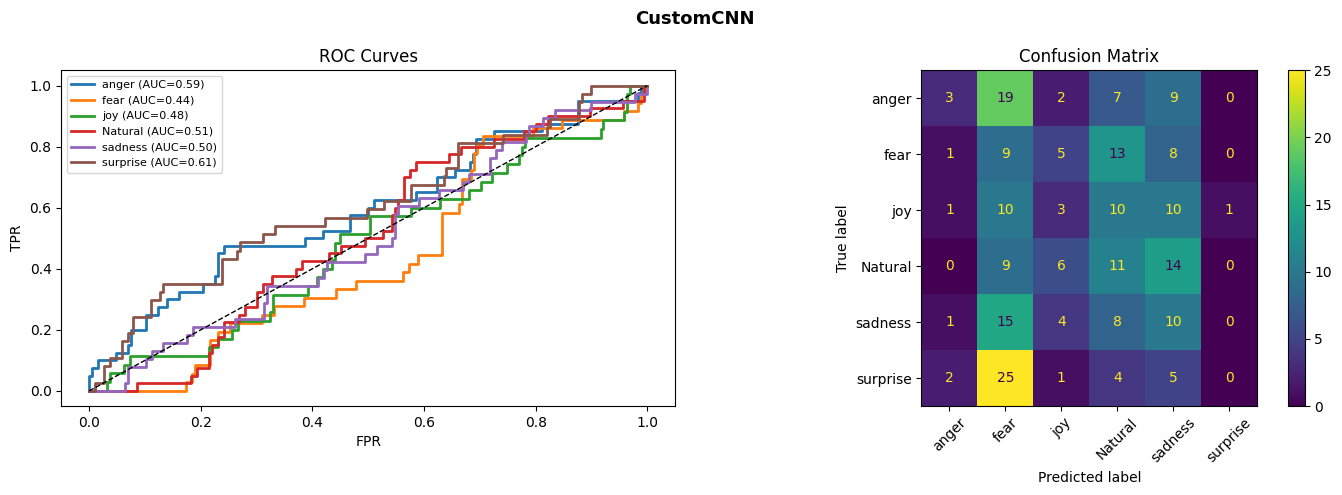

Saved → /content/drive/MyDrive/Autism_Dataset/CustomCNN_7ch.pth

  Training: ResNet18
Epoch [1/25]  Train Loss: 1.7239  Acc: 25.73%  |  Val Loss: 1.5356  Acc: 46.44%
Epoch [2/25]  Train Loss: 1.3855  Acc: 52.20%  |  Val Loss: 1.2668  Acc: 56.90%
Epoch [3/25]  Train Loss: 1.0271  Acc: 69.46%  |  Val Loss: 1.0834  Acc: 61.92%
Epoch [4/25]  Train Loss: 0.7255  Acc: 77.41%  |  Val Loss: 0.9603  Acc: 71.55%
Epoch [5/25]  Train Loss: 0.5285  Acc: 84.31%  |  Val Loss: 0.8564  Acc: 74.90%
Epoch [6/25]  Train Loss: 0.3838  Acc: 88.08%  |  Val Loss: 0.8921  Acc: 76.15%
Epoch [7/25]  Train Loss: 0.2818  Acc: 90.79%  |  Val Loss: 0.8273  Acc: 72.38%
Epoch [8/25]  Train Loss: 0.2376  Acc: 93.20%  |  Val Loss: 0.7945  Acc: 76.99%
Epoch [9/25]  Train Loss: 0.1670  Acc: 95.50%  |  Val Loss: 0.7367  Acc: 77.82%
Epoch [10/25]  Train Loss: 0.1661  Acc: 95.08%  |  Val Loss: 0.8493  Acc: 76.57%
Epoch [11/25]  Train Loss: 0.1394  Acc: 95.92%  |  Val Loss: 0.8225  Acc: 76.99%
Epoch [12/25]  Train Loss: 0.130

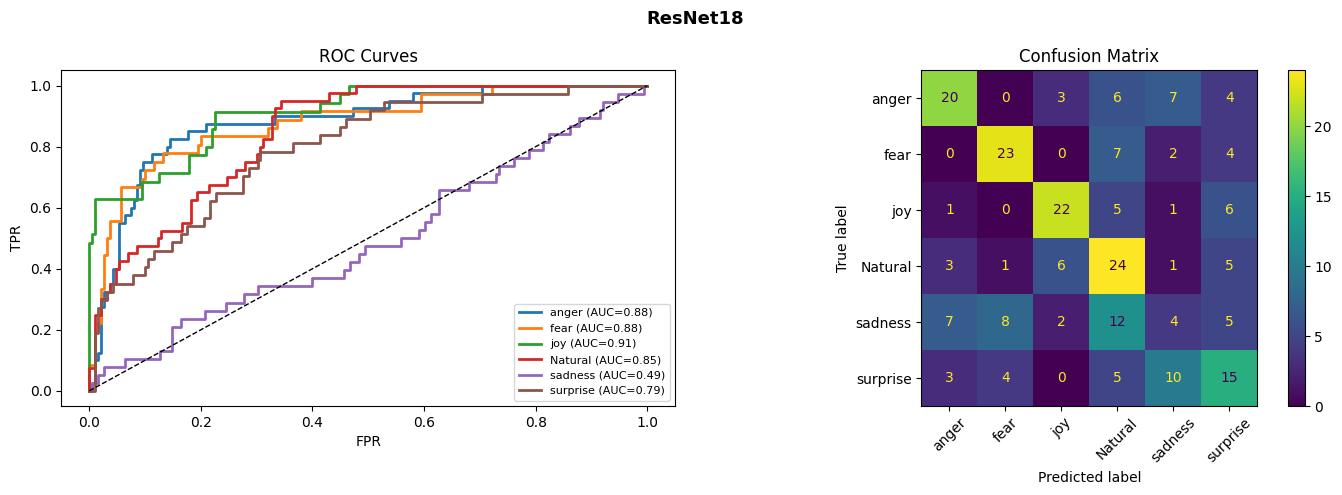

Saved → /content/drive/MyDrive/Autism_Dataset/ResNet18_7ch.pth

  Training: ViT
Epoch [1/25]  Train Loss: 1.7507  Acc: 33.05%  |  Val Loss: 1.3763  Acc: 47.70%
Epoch [2/25]  Train Loss: 0.9907  Acc: 64.75%  |  Val Loss: 0.9507  Acc: 64.44%
Epoch [3/25]  Train Loss: 0.4978  Acc: 83.79%  |  Val Loss: 0.9146  Acc: 73.22%
Epoch [4/25]  Train Loss: 0.2936  Acc: 91.11%  |  Val Loss: 0.9772  Acc: 74.06%
Epoch [5/25]  Train Loss: 0.2158  Acc: 93.62%  |  Val Loss: 0.9652  Acc: 74.06%
Epoch [6/25]  Train Loss: 0.2000  Acc: 94.46%  |  Val Loss: 0.9973  Acc: 71.55%
Epoch [7/25]  Train Loss: 0.1743  Acc: 94.46%  |  Val Loss: 1.0484  Acc: 75.73%
Epoch [8/25]  Train Loss: 0.1449  Acc: 94.87%  |  Val Loss: 0.9473  Acc: 77.41%
Epoch [9/25]  Train Loss: 0.0777  Acc: 96.76%  |  Val Loss: 1.0556  Acc: 76.57%
Epoch [10/25]  Train Loss: 0.0717  Acc: 96.44%  |  Val Loss: 1.0637  Acc: 78.24%
Epoch [11/25]  Train Loss: 0.0650  Acc: 97.38%  |  Val Loss: 1.0367  Acc: 76.57%
Epoch [12/25]  Train Loss: 0.0690  Acc

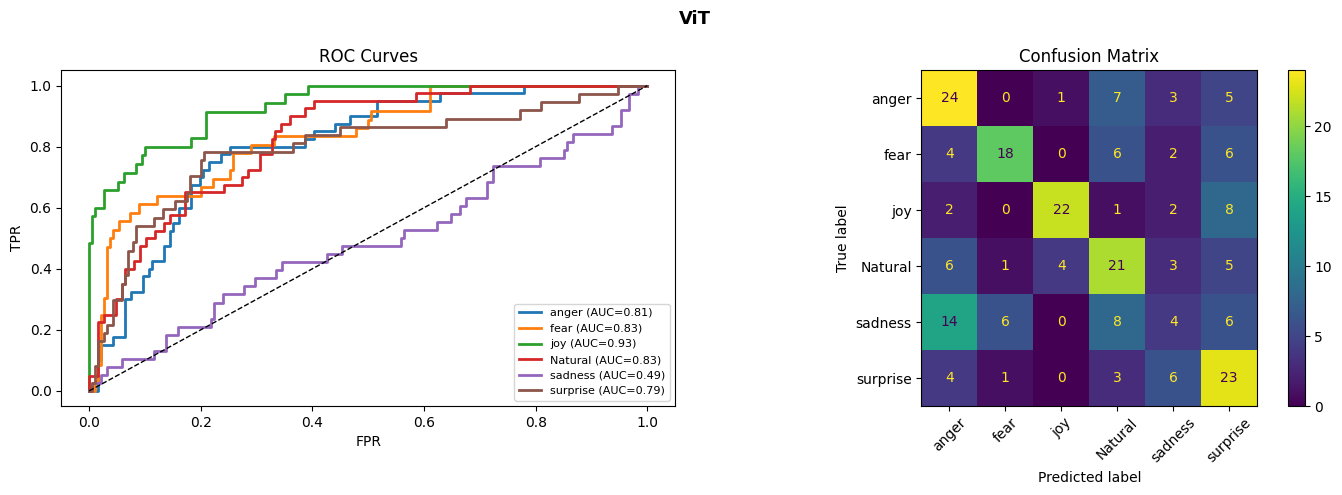

Saved → /content/drive/MyDrive/Autism_Dataset/ViT_7ch.pth

  Training: MultiVit
Epoch [1/25]  Train Loss: 1.9327  Acc: 15.48%  |  Val Loss: 1.8199  Acc: 18.41%
Epoch [2/25]  Train Loss: 1.8508  Acc: 18.41%  |  Val Loss: 1.8195  Acc: 20.92%
Epoch [3/25]  Train Loss: 1.8223  Acc: 18.31%  |  Val Loss: 1.8355  Acc: 25.94%
Epoch [4/25]  Train Loss: 1.7550  Acc: 24.58%  |  Val Loss: 1.6659  Acc: 37.24%
Epoch [5/25]  Train Loss: 1.5384  Acc: 39.96%  |  Val Loss: 1.4655  Acc: 38.08%
Epoch [6/25]  Train Loss: 1.1189  Acc: 59.00%  |  Val Loss: 1.2851  Acc: 47.28%
Epoch [7/25]  Train Loss: 0.8426  Acc: 70.40%  |  Val Loss: 1.2816  Acc: 57.32%
Epoch [8/25]  Train Loss: 0.4989  Acc: 82.85%  |  Val Loss: 1.0221  Acc: 69.04%
Epoch [9/25]  Train Loss: 0.3214  Acc: 90.38%  |  Val Loss: 1.1290  Acc: 67.78%
Epoch [10/25]  Train Loss: 0.2263  Acc: 91.95%  |  Val Loss: 1.4532  Acc: 62.76%
Epoch [11/25]  Train Loss: 0.2007  Acc: 93.72%  |  Val Loss: 1.4140  Acc: 71.55%
Epoch [12/25]  Train Loss: 0.2113  Acc

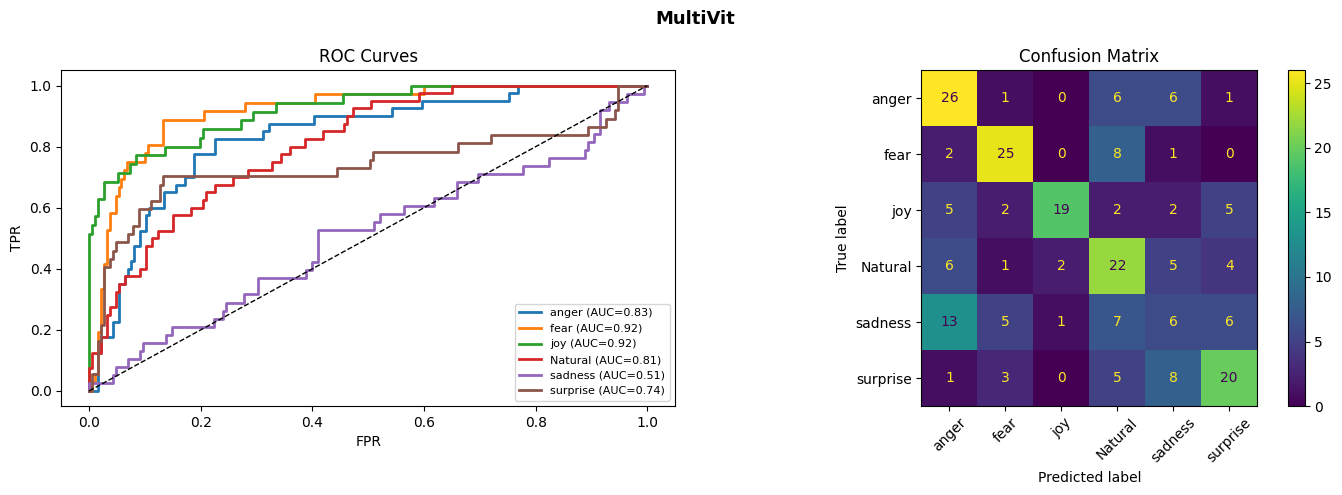

Saved → /content/drive/MyDrive/Autism_Dataset/MultiVit_7ch.pth


In [ ]:
NUM_EPOCHS = 50

models_dict = {
    'ResNet18':    ResNet18_7ch(num_classes=6, pretrained=True).to(device),
    'ViT':         ViT_7ch(num_classes=6, pretrained=True).to(device),
    'MultiVit':    multi_scaleVit(num_classes=6, pretrained=True).to(device)
}

for model_name, model in models_dict.items():
    print(f"\n{'='*55}")
    print(f'  Training: {model_name}')
    print(f"{'='*55}")

    trained_model = training(model, NUM_EPOCHS, device)
    test_phase(trained_model, test_loader, device, model_name=model_name)

    save_path = f'/content/drive/MyDrive/Autism_Dataset/{model_name}_7ch.pth'
    torch.save(trained_model.state_dict(), save_path)
    print(f'Saved → {save_path}')